# Train–Test Split

Machine learning models must be evaluated on unseen data to check how well they generalize.  
This section demonstrates how to properly split a dataset, keep class balance using **stratification**, and perform **scaling** safely without data leakage.

>### Why Split Data?
- The **training set** is used to teach the model patterns in the data.
- The **testing set** is used to evaluate how well the model performs on unseen data.

A typical ratio is **80% training** and **20% testing**.  Without this separation, a model might only memorize data instead of learning to generalize.

>### What is Stratification?
In classification tasks, the target variable often contains categories (for example, `survived` = 0 or 1 in the Titanic dataset).  
**Stratification** ensures that both the training and testing sets maintain the same class proportions as the full dataset.

For example, if 38% of passengers survived overall, both subsets will also contain about 38% survivors.  This prevents class imbalance from skewing results.

>### Preventing Data Leakage
Data leakage happens when information from the test set accidentally influences model training.  
To prevent this:
- Fit preprocessing steps like **scaling**, **encoding**, or **imputation** only on the **training set**.
- Apply those transformations to the test set later.

This ensures a fair, realistic model evaluation.

## Example 1: Basic Random Split (No Stratification)

This example divides the Titanic dataset randomly into training and test sets.  
- Each record has an equal chance of ending up in either set.

### Why It Matters
A random split is simple but can slightly distort the class ratio.  
- For instance, if the dataset has 38% survivors overall, the training set might end up with only 34%.  
    - Such differences can lead to misleading accuracy scores in classification tasks.

In [16]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Select two numeric features (age, fare) and the target variable
X = df[["age", "fare"]].fillna(0)
y = df["survived"].fillna(0)

# The 'train_test_split' function divides the dataset into two parts:
#   - Training set → used by the model to learn
#   - Testing set  → used later to check how well the model performs on unseen data
#
# test_size=0.2    → 20% of the data will be reserved for testing
# random_state=42  → ensures the split is reproducible each time the code runs

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test data
    random_state=42      # reproducibility
)

# Display shapes
print("Training set shape:", X_train.shape)
print("Testing  set shape:", X_test.shape)

# Compare survival rates to check for imbalance
print("\nSurvival rate in full dataset:", y.mean().round(3))
print("Survival rate in training set:", y_train.mean().round(3))
print("Survival rate in testing  set:", y_test.mean().round(3))

Training set shape: (712, 2)
Testing  set shape: (179, 2)

Survival rate in full dataset: 0.384
Survival rate in training set: 0.376
Survival rate in testing  set: 0.413


## Example 2: Stratified Split (Classification)

Here the dataset is split while **preserving the same class proportions** in both subsets.  

### Why It’s Important
In real-world datasets, one class often appears much more frequently than the other.  
- Without stratification, the training set might contain too few samples from the minority class, causing the model to perform poorly on those cases.

By stratifying, the **survival ratio** in both training and test sets closely matches the full dataset,  
which ensures fair evaluation.

In [17]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

df = sns.load_dataset("titanic")
X = df[["age", "fare"]].fillna(0)
y = df["survived"].fillna(0)

# The 'train_test_split' function divides the dataset into two parts:
#   - Training set → used by the model to learn
#   - Testing set  → used later to check how well the model performs on unseen data
#
# test_size=0.2   → 20% of the data will be reserved for testing
# stratify=y       → ensures that both subsets (train and test) have the same class proportions
#                    Example: if 38% of passengers survived in the full dataset,
#                    both training and test sets will have about 38% survivors.
# random_state=42  → ensures the split is reproducible each time the code runs

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    stratify=y,          # preserve class balance
    random_state=42      # reproducibility
)


# Check dataset sizes and survival rates
print("Training set shape:", X_train.shape)
print("Testing  set shape:", X_test.shape)

print("\nSurvival proportion (class=1):")
print("Full dataset :", y.mean().round(3))
print("Training set :", y_train.mean().round(3))
print("Testing set  :", y_test.mean().round(3))

Training set shape: (712, 2)
Testing  set shape: (179, 2)

Survival proportion (class=1):
Full dataset : 0.384
Training set : 0.383
Testing set  : 0.385


## Example 3: Stratified Split with Standardization

In this example, scaling (standardization) is applied **after** splitting the data.  
- This prevents information from the test set from leaking into the training process.

### Why Standardize?
Machine learning algorithms often work best when features are on a similar numeric scale.  
- For example, `age` may range from 0–80, while `fare` can range in hundreds.  
- Standardization rescales these values so that each feature has:

$$ z = \frac{x - \mu}{\sigma} $$

where \( \mu \) is the mean and \( \sigma \) is the standard deviation.  
After transformation, each feature has a mean near **0** and standard deviation near **1**.

**Key steps:**
1. Perform a stratified split (to preserve class balance).  
2. Fit the `StandardScaler` on the **training data only**.  
3. Apply the same transformation to both training and test sets.  
4. Verify results by checking feature statistics before and after scaling.

Scaled feature statistics:
       Train Mean  Train Std  Test Mean  Test Std
age          0.0        1.0     -0.078     1.014
fare        -0.0        1.0      0.040     1.160


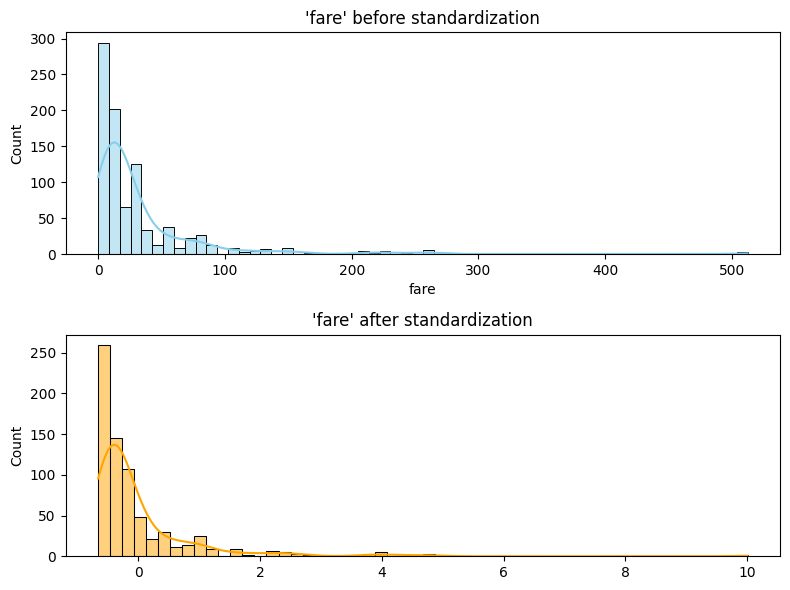

In [18]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load Titanic dataset
df = sns.load_dataset("titanic")
X = df[["age", "fare"]].fillna(0)
y = df["survived"].fillna(0)

# Step 1: Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Fit scaler on training data only
scaler = StandardScaler()
scaler.fit(X_train)

# Step 3: Apply same transformation to both sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 4: Check scaling results
stats = pd.DataFrame({
    "Train Mean": X_train_scaled.mean(axis=0),
    "Train Std" : X_train_scaled.std(axis=0, ddof=0),
    "Test Mean" : X_test_scaled.mean(axis=0),
    "Test Std"  : X_test_scaled.std(axis=0, ddof=0)
}, index=X.columns).round(3)
print("Scaled feature statistics:\n", stats)

# Step 5: Visual comparison (before vs after)
feature = "fare"
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
sns.histplot(X[feature], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title(f"'{feature}' before standardization")
sns.histplot(X_train_scaled[:, X.columns.get_loc(feature)], kde=True, ax=axes[1], color="orange")
axes[1].set_title(f"'{feature}' after standardization")
plt.tight_layout()
plt.show()